# Data Audit

Download four ETFs, validate data quality, and save a clean adjusted-close panel.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root (works whether you run from notebooks/ or project root)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import (
    load_config,
    download_etf_data,
    build_adj_close_panel,
    build_close_panel,
    build_dividend_panel,
    get_common_sample,
)
from src.data_validation import (
    audit_table,
    check_date_continuity,
    return_audit,
    flag_large_moves,
    verify_dividend_adjustment,
)

config = load_config(ROOT / "config" / "settings.json")

# Show what we're working with
print("ETF Universe:")
for ticker, info in config["etf_universe"].items():
    print(f"  {ticker:14s}  {info['label']:12s}  ({info['role']}, {info['exchange']})")
print(f"\nDownload start: {config['download']['start_date']}")


ETF Universe:
  0050.TW         元大台灣50        (core_equity, TWSE)
  00713.TW        元大高息低波        (defensive_equity, TWSE)
  00679B.TWO      元大美債20年       (long_treasury, TPEx)
  00635U.TW       元大S&P黃金       (gold, TWSE)

Download start: 2017-01-01


## 1. Download

Using `auto_adjust=False` + `actions=True` to get Adj Close, unadjusted Close,
and Dividends separately — the latter two are needed to verify the adjustment.


In [2]:
tickers = list(config["etf_universe"].keys())

# This will raise a clear error if any ticker returns empty data
# (e.g. wrong exchange suffix)
ticker_data = download_etf_data(
    tickers=tickers,
    start=config["download"]["start_date"],
    end=config["download"].get("end_date"),
)

print(f"Downloaded {len(ticker_data)} tickers.")
for t, df in ticker_data.items():
    print(f"  {t}: {len(df)} rows, {df.index.min().date()} to {df.index.max().date()}")


Downloaded 4 tickers.
  0050.TW: 2319 rows, 2017-01-03 to 2026-07-22
  00713.TW: 2319 rows, 2017-01-03 to 2026-07-22
  00679B.TWO: 2319 rows, 2017-01-03 to 2026-07-22
  00635U.TW: 2319 rows, 2017-01-03 to 2026-07-22


## 2. Audit


In [3]:
adj_close   = build_adj_close_panel(ticker_data)
unadj_close = build_close_panel(ticker_data)
dividends   = build_dividend_panel(ticker_data)

print("Adj Close panel shape:", adj_close.shape)
audit = audit_table(adj_close)
audit


Adj Close panel shape: (2319, 4)


,first_valid_date,last_valid_date,n_observations,n_missing,missing_pct
0050.TW,2017-01-03,2026-07-22,2319,0,0.00
00713.TW,2017-09-19,2026-07-22,2147,172,7.42
00679B.TWO,2017-01-11,2026-07-22,2312,7,0.30
00635U.TW,2017-01-03,2026-07-22,2319,0,0.00


## 3. Common sample


In [4]:
common_adj   = get_common_sample(adj_close)
common_unadj = unadj_close.loc[common_adj.index]
common_div   = dividends.loc[common_adj.index]

# Basic assertions
assert common_adj.notna().all().all(),          "NaN found in common sample"
assert common_adj.index.is_monotonic_increasing, "Index not sorted"
assert common_adj.index.is_unique,               "Duplicate dates"
assert (common_adj > 0).all().all(),             "Non-positive prices found"

print(f"Common sample: {common_adj.index.min().date()} to {common_adj.index.max().date()}")
print(f"Trading days:  {len(common_adj)}")
print(f"Years:         {len(common_adj) / 252:.1f}")


Common sample: 2017-09-19 to 2026-07-22
Trading days:  2147
Years:         8.5


## 4. Date continuity

`dropna` guarantees no NaNs, but doesn't guarantee contiguous trading dates.


In [5]:
suspicious_gaps = check_date_continuity(common_adj, max_gap_days=15)


Date continuity OK, no gaps > 15 days.


## 5. Return statistics and large-move screening


In [6]:
rstats = return_audit(common_adj)
rstats


,mean,std,min,max,annualized_return,annualized_vol,min_date,max_date
0050.TW,0.000969,0.013103,-0.100000,0.099863,0.2442,0.2080,2025-04-07,2025-04-10
00713.TW,0.000625,0.008039,-0.099905,0.099008,0.1574,0.1276,2025-04-07,2025-04-10
00679B.TWO,-0.000010,0.008816,-0.071532,0.085691,-0.0026,0.1400,2025-05-05,2020-03-09
00635U.TW,0.000405,0.010816,-0.110932,0.077402,0.1021,0.1717,2026-02-02,2026-01-29


In [7]:
large = flag_large_moves(common_adj, threshold=0.08)


Found 7 moves exceeding ±8%:
                         return
Date                           
2026-02-02 00635U.TW  -0.110932
2025-04-07 0050.TW    -0.100000
           00713.TW   -0.099905
2024-08-05 0050.TW    -0.091299
2020-03-09 00679B.TWO  0.085691
2025-04-10 00713.TW    0.099008
           0050.TW     0.099863


## 6. Dividend adjustment verification

yfinance's Adj Close isn't always reliable for Taiwan ETFs. Cross-check
implied dividends from the adjusted series against reported amounts.


In [8]:
print("Dividend adjustment verification:")
print("=" * 60)

div_reports = {}
for ticker in tickers:
    adj_s   = common_adj[ticker]
    unadj_s = common_unadj[ticker]
    div_s   = common_div[ticker]
    report  = verify_dividend_adjustment(adj_s, unadj_s, div_s, ticker, n_checks=5)
    div_reports[ticker] = report

# Show detail for the most critical ones (bond and high-div ETFs)
for ticker in ["00679B.TWO", "00713.TW"]:
    if ticker in div_reports and len(div_reports[ticker]) > 0:
        print(f"\nDetail for {ticker}:")
        print(div_reports[ticker].to_string(index=False))


Dividend adjustment verification:
  0050.TW: 5/5 dividend adjustments OK.
  00713.TW: 5/5 dividend adjustments OK.
  00679B.TWO: 5/5 dividend adjustments OK.
  00635U.TW: no dividends recorded.

Detail for 00679B.TWO:
   ex_date  dividend  close_before  implied_dividend  discrepancy_bps status
2025-05-22      0.32         25.49            0.3139              2.4     OK
2025-08-21      0.28         25.95            0.2831              1.2     OK
2025-11-21      0.28         27.51            0.2821              0.7     OK
2026-02-26      0.28         27.84            0.2799              0.0     OK
2026-05-22      0.28         26.22            0.2812              0.5     OK

Detail for 00713.TW:
   ex_date  dividend  close_before  implied_dividend  discrepancy_bps status
2025-06-20      1.10         51.65            1.0935              1.3     OK
2025-09-19      0.78         51.85            0.7820              0.4     OK
2025-12-19      0.78         51.15            0.7874              1

## 7. Cumulative total return


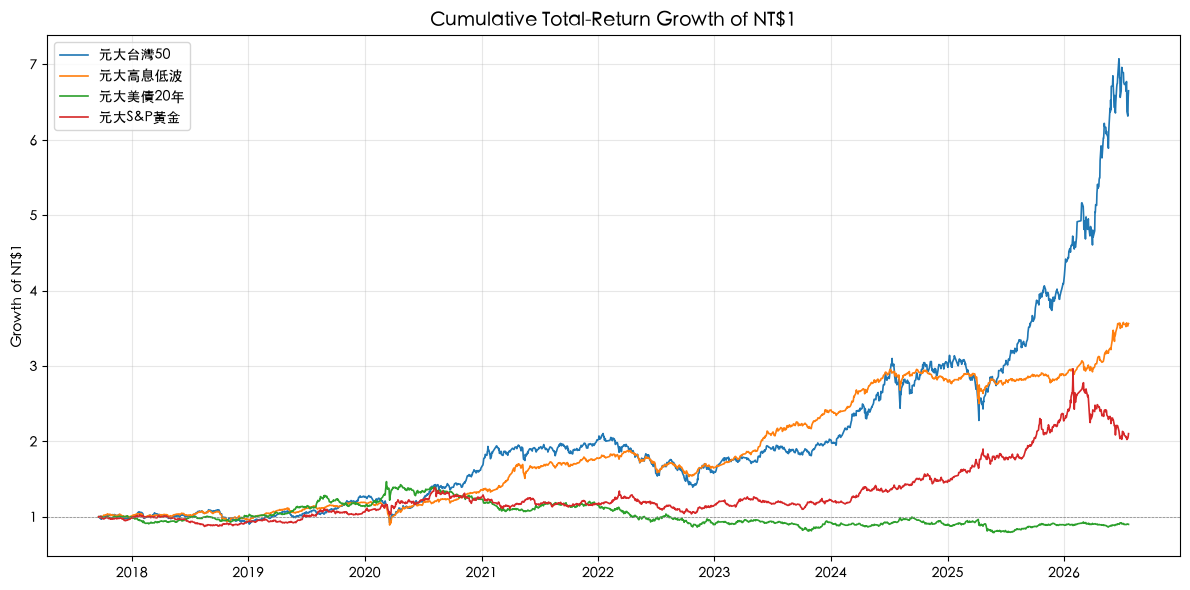

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/cumulative_return.png


In [9]:
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
labels = {t: info["label"] for t, info in config["etf_universe"].items()}

normalized = common_adj / common_adj.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=labels.get(col, col), linewidth=1.2)

ax.set_title("Cumulative Total-Return Growth of NT$1", fontsize=14)
ax.set_ylabel("Growth of NT$1")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.5)
plt.tight_layout()

fig_path = ROOT / "figures" / "cumulative_return.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 8. Correlation matrix


Daily return correlations:
         元大台灣50  元大高息低波  元大美債20年  元大S&P黃金
元大台灣50    1.000   0.703   -0.109    0.179
元大高息低波    0.703   1.000   -0.048    0.169
元大美債20年  -0.109  -0.048    1.000    0.172
元大S&P黃金   0.179   0.169    0.172    1.000


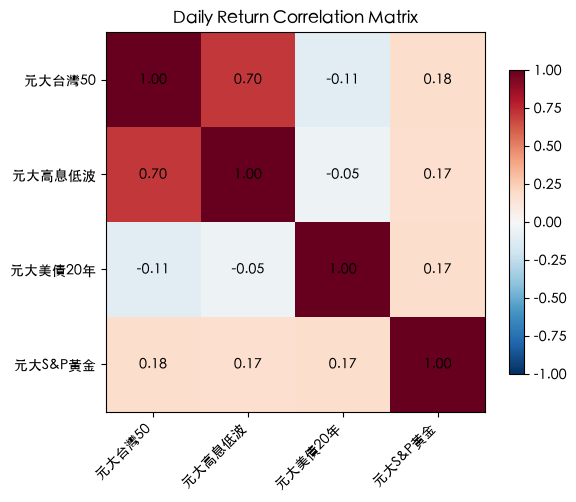

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/correlation_matrix.png


In [10]:
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
daily_rets = common_adj.pct_change().dropna()
daily_rets.columns = [labels.get(c, c) for c in daily_rets.columns]

corr = daily_rets.corr()
print("Daily return correlations:")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Daily Return Correlation Matrix")
plt.tight_layout()

fig_path2 = ROOT / "figures" / "correlation_matrix.png"
fig.savefig(fig_path2, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path2}")


## 9. Save


In [11]:
out_dir = ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

# Save adj close (primary working dataset)
common_adj.to_parquet(out_dir / "adj_close.parquet")
common_adj.to_csv(out_dir / "adj_close.csv", encoding="utf-8-sig")

# Save unadjusted close and dividends (for future verification)
common_unadj.to_parquet(out_dir / "unadj_close.parquet")
common_div.to_parquet(out_dir / "dividends.parquet")

print("Saved to", out_dir)
for f in sorted(out_dir.glob("*")):
    print(f"  {f.name}")


Saved to /Users/leeyuhung/Desktop/regime-etf-allocation/data/processed
  .gitkeep
  adj_close.csv
  adj_close.parquet
  dividends.parquet
  unadj_close.parquet


## Notes

- **00679B** is an unhedged USD bond ETF. TWD/USD moves are baked into the return series
  (the May 2025 TWD spike is visible in the data, not a data error).
- **00635U** is a futures-based gold ETF with ~1.5-2% annual roll cost embedded in prices.
- Cash proxy in config uses a fixed 1.5% annual rate (approximate Taiwan 1Y deposit rate).
